In [116]:
# Author: A.M.Kharazi
# License: BSD 3 clause

# Add to the path

In [6]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')
import os


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Import Libraries

In [4]:
# !pip install einops
# !pip install tensorly
# !pip install tensorly-torch

  Using cached tensorly-0.9.0-py3-none-any.whl.metadata (8.6 kB)
Using cached tensorly-0.9.0-py3-none-any.whl (7.4 MB)
  Using cached tensorly_torch-0.5.0-py3-none-any.whl.metadata (4.6 kB)
Using cached tensorly_torch-0.5.0-py3-none-any.whl (59 kB)


In [7]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch import optim
from einops import rearrange
from sklearn.model_selection import train_test_split

import tltorch
from Utils.Reshape import reshape
from Utils.Num_parameter import count_parameters

# Synthetic Data

device is set to : cpu


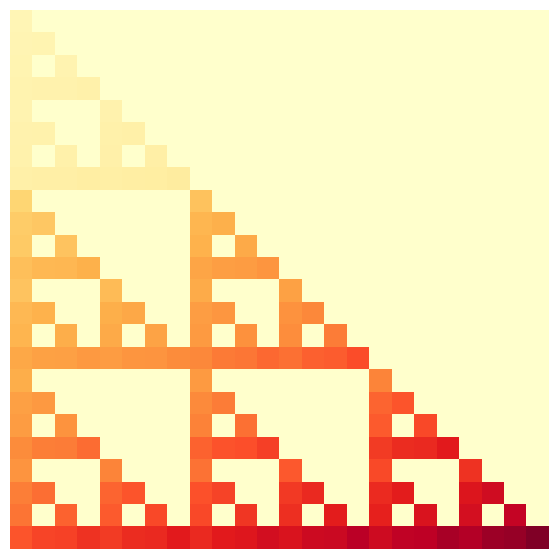

In [14]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device is set to : {device}')

ablation = ['./PLUS/', './DIAGONAL/', './DIAGONAL-version2/', './UPPER-TRIANGULAR-allmodelswork/', './UPPER-TRIANGULAR-allmodelswork-version2/'
            , './UPPER-TRIANGULAR-justourmodelworks/', './LOWER-TRIANGULAR/']

root = ablation[6]
if(not os.path.exists(root)):
   os.mkdir(root)

def generate_samples(n_samples, size):
    mean = 0
    variance = 3
    std_dev = torch.sqrt(torch.tensor(variance))
    tensor = np.random.normal(mean, std_dev, (n_samples, size))
    tensor = torch.tensor(tensor, dtype=torch.float32)

    # ## PLUS
    # w1 = torch.tensor([[0,1,0],[1,1,1],[0,1,0]], dtype=torch.float32).to(device)
    # w2 = torch.tensor([[3,6],[9,12]], dtype=torch.float32).to(device)
    # w3 = torch.tensor([[5,10],[15,20]], dtype=torch.float32).to(device)
    # w4 = torch.tensor([[11,13],[17,23]], dtype=torch.float32).to(device)

    ## DIAGONAL
    # w1 = torch.tensor([[1, 0, 0], [0, 2, 0], [0, 0, 3]], dtype=torch.float32).to(device) 
    # w2 = torch.tensor([[4, 0], [0, 5]], dtype=torch.float32).to(device) 
    # w3 = torch.tensor([[6, 0], [0, 7]], dtype=torch.float32).to(device) 
    # w4 = torch.tensor([[8, 0], [0, 9]], dtype=torch.float32).to(device)
    
    ## DIAGONAL version2
    # w1 = torch.tensor([[0,0,10],[0,10,0],[10,0,0]], dtype=torch.float32).to(device)
    # w2 = torch.tensor([[0,6],[9,0]], dtype=torch.float32).to(device)
    # w3 = torch.tensor([[0,10],[15,0]], dtype=torch.float32).to(device)
    # w4 = torch.tensor([[0,13],[17,0]], dtype=torch.float32).to(device)

    ## UPPER TRIANGULAR - all models work
    # w1 = torch.tensor([[1, 2, 3], [0, 1, 4], [0, 0, 1]], dtype=torch.float32).to(device) 
    # w2 = torch.tensor([[1, 2], [0, 1]], dtype=torch.float32).to(device) 
    # w3 = torch.tensor([[1, 2], [0, 1]], dtype=torch.float32).to(device) 
    # w4 = torch.tensor([[1, 2], [0, 1]], dtype=torch.float32).to(device)

    ## UPPER TRIANGULAR - all models work - version2 
    # w1 = torch.tensor([[1, 2, 3], [0, 1, 4], [0, 0, 1]], dtype=torch.float32).to(device)
    # w2 = torch.tensor([[1, 2], [0, 1]], dtype=torch.float32).to(device)
    # w3 = torch.tensor([[1, 2], [0, 1]], dtype=torch.float32).to(device) 
    # w4 = torch.tensor([[1, 2], [0, 1]], dtype=torch.float32).to(device)

    ## UPPER TRIANGULAR - just our model works
    # w1 = torch.tensor([[1, 2, 3], [0, 4, 5], [0, 0, 6]], dtype=torch.float32).to(device)
    # w2 = torch.tensor([[7, 8], [0, 9]], dtype=torch.float32).to(device) 
    # w3 = torch.tensor([[10, 11], [0, 12]], dtype=torch.float32).to(device) 
    # w4 = torch.tensor([[13, 14], [0, 15]], dtype=torch.float32).to(device)

    ## LOWER TRIANGULAR
    w1 = torch.tensor([[1, 0, 0], [4, 5, 0], [6, 7, 8]], dtype=torch.float32).to(device) 
    w2 = torch.tensor([[9, 0], [11, 12]], dtype=torch.float32).to(device) 
    w3 = torch.tensor([[13, 0], [15, 16]], dtype=torch.float32).to(device) 
    w4 = torch.tensor([[17, 0], [19, 20]], dtype=torch.float32).to(device)

    Weight = w1.kron(w2).kron(w3).kron(w4)
    Weight = Weight.to(torch.float32).to(device)

    output  = torch.matmul(tensor, Weight)

    mean = 0
    variance = 1
    std_dev = torch.sqrt(torch.tensor(variance))
    noise = np.random.normal(mean, std_dev, (n_samples, size))
    noise = torch.tensor(noise, dtype=torch.float32).to(device)

    return tensor.to(device), output.to(device), Weight.to(device), (tensor+noise).to(device)

n_samples = 100
size = 3*2*2*2

samples, y, W, x = generate_samples(n_samples, size)


fig = plt.figure(figsize=(10,7))
plt.imshow(W.cpu(), cmap='YlOrRd')
plt.axis('off')
# plt.title('Ground Truth', fontsize = 20)
plt.savefig(root + 'W.png')
plt.show()


X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)


# Basic Linear Model

This Model has : 576 parameters
RMSE of Train : 77347.28002974635
RMSE of Test  : 84067.59642097543
RMSE of Ws  : 8847.65822124702


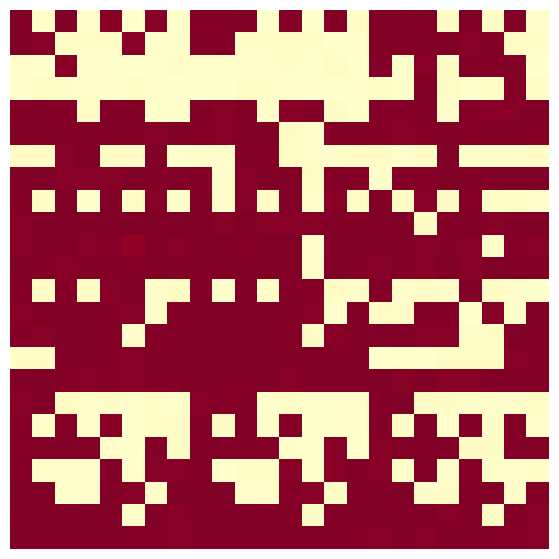

In [15]:
class simple_linear(nn.Module):
    def __init__(self):
        super(simple_linear, self).__init__()
        self.fc = nn.Linear(in_features= size, out_features=size, bias=False)
    def forward(self, x):
        return self.fc(x)
    
model = simple_linear().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    loss.backward()
    optimizer.step()

W_fc = model.fc.weight

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(X_test), y_test).item())}')
print(f'RMSE of Ws  : {np.sqrt(criterion(W, W_fc).item())}')

fig = plt.figure(figsize=(10,7))
plt.imshow(W_fc.detach().cpu().T, cmap='YlOrRd')
plt.axis('off')
# plt.title(f'linear regression - {count_parameters(model)} #p - RMSE {np.sqrt(criterion(model(X_test), y_test).item()):.3f}', fontsize = 20)
plt.savefig(root + 'linear.png')
plt.show()


# Basic TCL Model

This Model has : 148 parameters
RMSE of Train : 76495.091398076
RMSE of Test  : 83325.13973585643
RMSE of Ws  : 8811.462080721905


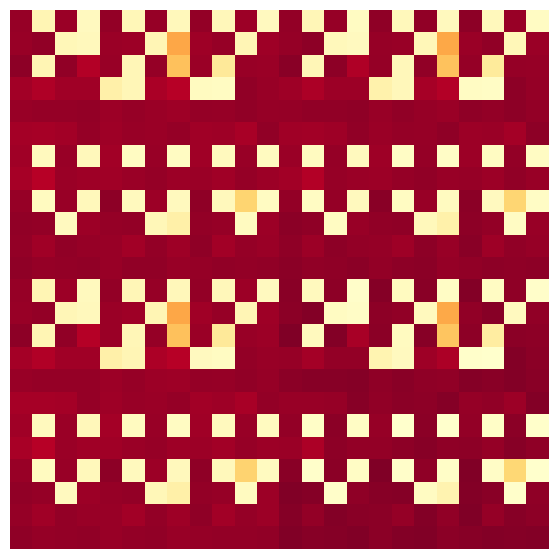

In [16]:
class simple_tcl(nn.Module):
    def __init__(self):
        super(simple_tcl, self).__init__()
        self.tcl = tltorch.TCL(input_shape=(2,size//2), rank=(2,size//2), bias=False)
    def forward(self, x):
        return self.tcl(x.reshape(-1,2,12))
    
model = simple_tcl().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    outputs = outputs.reshape(-1, size)
    loss = criterion(outputs, y_train)

    loss.backward()
    optimizer.step()
    
W_tcl1 = model.tcl.factors[0].kron(model.tcl.factors[1])

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train).reshape(-1, size), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(X_test).reshape(-1, size), y_test).item())}')
print(f'RMSE of Ws  : {np.sqrt(criterion(W, W_tcl1).item())}')

fig = plt.figure(figsize=(10,7))
plt.imshow(W_tcl1.detach().cpu().T, cmap='YlOrRd')
plt.axis('off')
# plt.title(f'trl (1,1) - {count_parameters(model)} #p - RMSE {np.sqrt(criterion(model(X_test), y_test).item()):.3f}', fontsize = 20)
plt.savefig(root + 'tcl.png')
plt.show()


# Basic Patching Model

model factor shapes
4
torch.Size([3, 3])
torch.Size([2, 2])
torch.Size([2, 2])
torch.Size([2, 2])
This Model has : 21 parameters
RMSE of Train : 31125.156385149297
RMSE of Test  : 36518.82320119311
RMSE of Ws  : 10434.314160499482


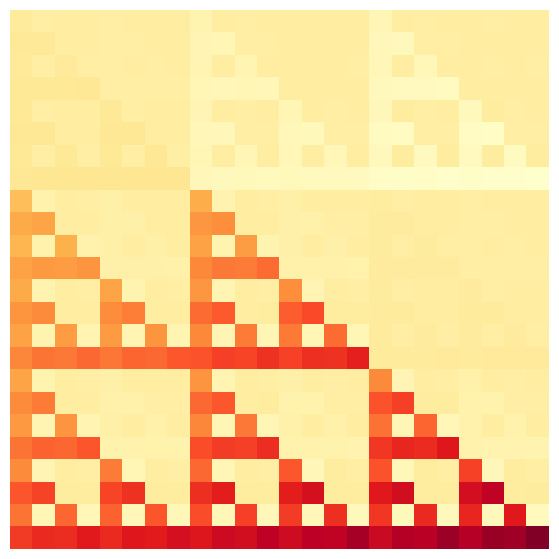

In [12]:
class simple_attached(nn.Module):
    def __init__(self):
        super(simple_attached, self).__init__()
        self.tcl = tltorch.TCL(input_shape=(3,2,2,2), rank=(3,2,2,2), bias=False)
    def forward(self, x):
        return self.tcl(x.reshape(-1,3,2,2,2))
    
model = simple_attached().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    outputs = outputs.reshape(-1,size)
    loss = criterion(outputs, y_train)
    
    loss.backward()
    optimizer.step()

print("model factor shapes")
print(len(model.tcl.factors))
print(model.tcl.factors[0].shape)
print(model.tcl.factors[1].shape)
print(model.tcl.factors[2].shape)
print(model.tcl.factors[3].shape)
W_attached1 = model.tcl.factors[0].kron(model.tcl.factors[1]).kron(model.tcl.factors[2]).kron(model.tcl.factors[3])

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train).reshape(-1,size), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(X_test).reshape(-1,size), y_test).item())}')
print(f'RMSE of Ws  : {np.sqrt(criterion(W, W_attached1).item())}')

fig = plt.figure(figsize=(10,7))
plt.imshow(W_attached1.detach().cpu().T, cmap='YlOrRd')
plt.axis('off')
# plt.title(f'attached - trl (1,1) - {count_parameters(model)} #p - RMSE {np.sqrt(criterion(model(X_test), y_test).item()):.3f}', fontsize = 20)
plt.savefig(root + 'ours.png')
plt.show()
